In [1624]:
import numpy as np
import pandas as pd
import scipy as sp

import matplotlib.pyplot as plt
import scipy.integrate

from uncertainties import ufloat
from uncertainties import umath
from uncertainties import unumpy as un

In [1625]:
df1 = pd.read_excel("p6electro.xlsx", sheet_name = "data1")
df2 = pd.read_excel("p6electro.xlsx", sheet_name = "data2")

dflaminado = pd.read_excel("datos_laminado.xlsx")
dfmacizo = pd.read_excel("datos_mazizo.xlsx")

In [1626]:
I = [un.uarray(df1["I"].to_numpy(), (1/100)*abs(df1["I"])+3*0.001),
     un.uarray(df2["I (A)"].to_numpy(), (1/100)*abs(df2["I (A)"])+3*0.001)]

B = [un.uarray(df1["B"].to_numpy(), df1["errB"].to_numpy()),
     un.uarray(df2["B"].to_numpy(), df2["err B"].to_numpy())]

In [1627]:
B = [b / 1000 for b in B]

In [1628]:
deleteThis = 94

B[0] = np.delete(B[0], deleteThis)
I[0] = np.delete(I[0], deleteThis)

In [1629]:
lMedia = [ufloat(36.3, 0.2),
          ufloat(33.8, 0.2)]

lMedia = [ele / 100 for ele in lMedia]

N = 1200

H = [N * 2 * intensidad / eleMedia for (intensidad, eleMedia) in zip(I, lMedia)]

In [1630]:
def merge_slices(s1, s2):
    if s1.step not in (None, 1) or s2.step not in (None, 1):
        raise ValueError("Only supports slices with step 1 or None")

    start = min(s1.start, s2.start)
    stop = max(s1.stop, s2.stop)

    return slice(start, stop)

In [1631]:
partOfThing = [[slice(0,26),slice(26,53),slice(53,75),slice(75,97),slice(97,-1)],
               [slice(0,25), slice(25,45), slice(45,69), slice(69,94), slice(94,-1)]]



In [1632]:
hysteresisLoss = [sp.integrate.simpson(un.nominal_values(H[0][26:-1]), x = un.nominal_values(B[0][26:-1]))
    ,
                  sp.integrate.simpson(un.nominal_values(H[1][26:-1]), x = un.nominal_values(B[1][26:-1]))]

hysteresisLoss = [hl / 1000000 * 1000 for hl in hysteresisLoss]

#print(f"Hysteresis loss for solid-core is : {hysteresisLoss[0]} mJ/cm^3")
#print(f"Hysteresis loss for laminated-core is : {hysteresisLoss[1]} mJ/cm^3")

hmacizo = dfmacizo["H"]
bmacizo = dfmacizo["B"]
errbmacizo = dfmacizo["errB"]

mid = len(hmacizo) // 2

mask = np.ones(len(hmacizo))
mask[mid:] = -1

aee = slice(5,35)
eea = slice(45,75)

biggestCaseMacizo = sp.integrate.simpson(hmacizo, bmacizo + errbmacizo*mask)
smallestCaseMacizo = sp.integrate.simpson(np.concatenate((hmacizo[aee], hmacizo[eea])),
                                          np.concatenate((
                                                            bmacizo[aee] - errbmacizo[aee] * mask[aee],
                                                            bmacizo[eea] - errbmacizo[eea] * mask[eea]
                                                        )))
normalMacizo = sp.integrate.simpson(hmacizo, bmacizo)

print(f"test = {normalMacizo} + {biggestCaseMacizo - normalMacizo} - {smallestCaseMacizo - normalMacizo}")

print(sp.integrate.simpson(dflaminado["H"], dflaminado["B"]) / 1000)

test = 1409.9164832235142 + 73.13357941799427 - -216.25288641774978
0.23248083007599427


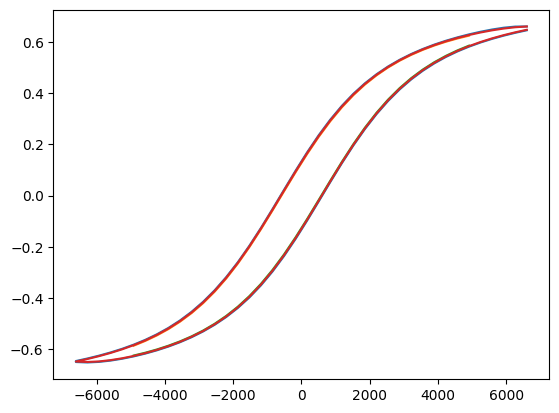

In [1633]:
aee = slice(5,35)
eea = slice(45,75)

plt.plot(hmacizo, bmacizo + errbmacizo*mask)
plt.plot(hmacizo[aee], (bmacizo - errbmacizo*mask)[aee])
plt.plot(hmacizo[eea], (bmacizo - errbmacizo*mask)[eea])
plt.plot(hmacizo, bmacizo)


In [1634]:
N = 20000
rng = np.random.default_rng(42)

H_nom = dfmacizo["H"]
#H_std = un.std_devs(H[0][26:-1])

B_nom = dfmacizo["B"]
B_std = dfmacizo["errB"]


W_samples = []
for _ in range(N):
    B_sample = rng.normal(B_nom, B_std)      # only B is perturbed, H is exact
    W = sp.integrate.simpson(H_nom, x=B_sample)
    W_samples.append(W)

W_samples = np.array(W_samples)
W_mean = W_samples.mean()
W_std  = W_samples.std(ddof=1)

print(f"W = {W_mean:.4f} ± {W_std:.4f} J/m³")
print(f"95% CI: [{np.percentile(W_samples,2.5):.4f}, {np.percentile(W_samples,97.5):.4f}]")

W = 1429.8145 ± 305.6471 J/m³
95% CI: [1380.2824, 1484.6582]


In [1635]:
N = 20000
rng = np.random.default_rng(44)

H_nom = dflaminado["H"]
#H_std = un.std_devs(H[0][26:-1])

B_nom = dflaminado["B"]
B_std = dflaminado["errB"]


W_samples = []
for _ in range(N):
    B_sample = rng.normal(B_nom, B_std)      # only B is perturbed, H is exact
    W = sp.integrate.simpson(H_nom, x=B_sample)
    W_samples.append(W)

W_samples = np.array(W_samples)
W_mean = W_samples.mean()
W_std  = W_samples.std(ddof=1)

print(f"W = {W_mean:.4f} ± {W_std:.4f} J/m³")
print(f"95% CI: [{np.percentile(W_samples,2.5):.4f}, {np.percentile(W_samples,97.5):.4f}]")

W = 268.2433 ± 461.4733 J/m³
95% CI: [98.7332, 434.1624]


In [1636]:

N = 5000  # number of simulations

W_samples = []

H_nom = dflaminado["H"]
#H_std = un.std_devs(H[0][26:-1])

B_nom = dflaminado["B"]
B_std = dflaminado["errB"]

for _ in range(N):
    H_sample = np.random.normal(H_nom, 0.1)
    B_sample = np.random.normal(B_nom, B_std)

    W = sp.integrate.simpson(H_sample, x=B_sample)
    W_samples.append(W)

W_samples = np.array(W_samples)

W_mean = np.mean(W_samples)
W_std  = np.std(W_samples)

W = ufloat(W_mean, W_std)

print(W/1000)

0.26+/-0.32


In [1637]:
np.trapezoid(H_nom, x = B_nom)

np.float64(267.81557990046286)

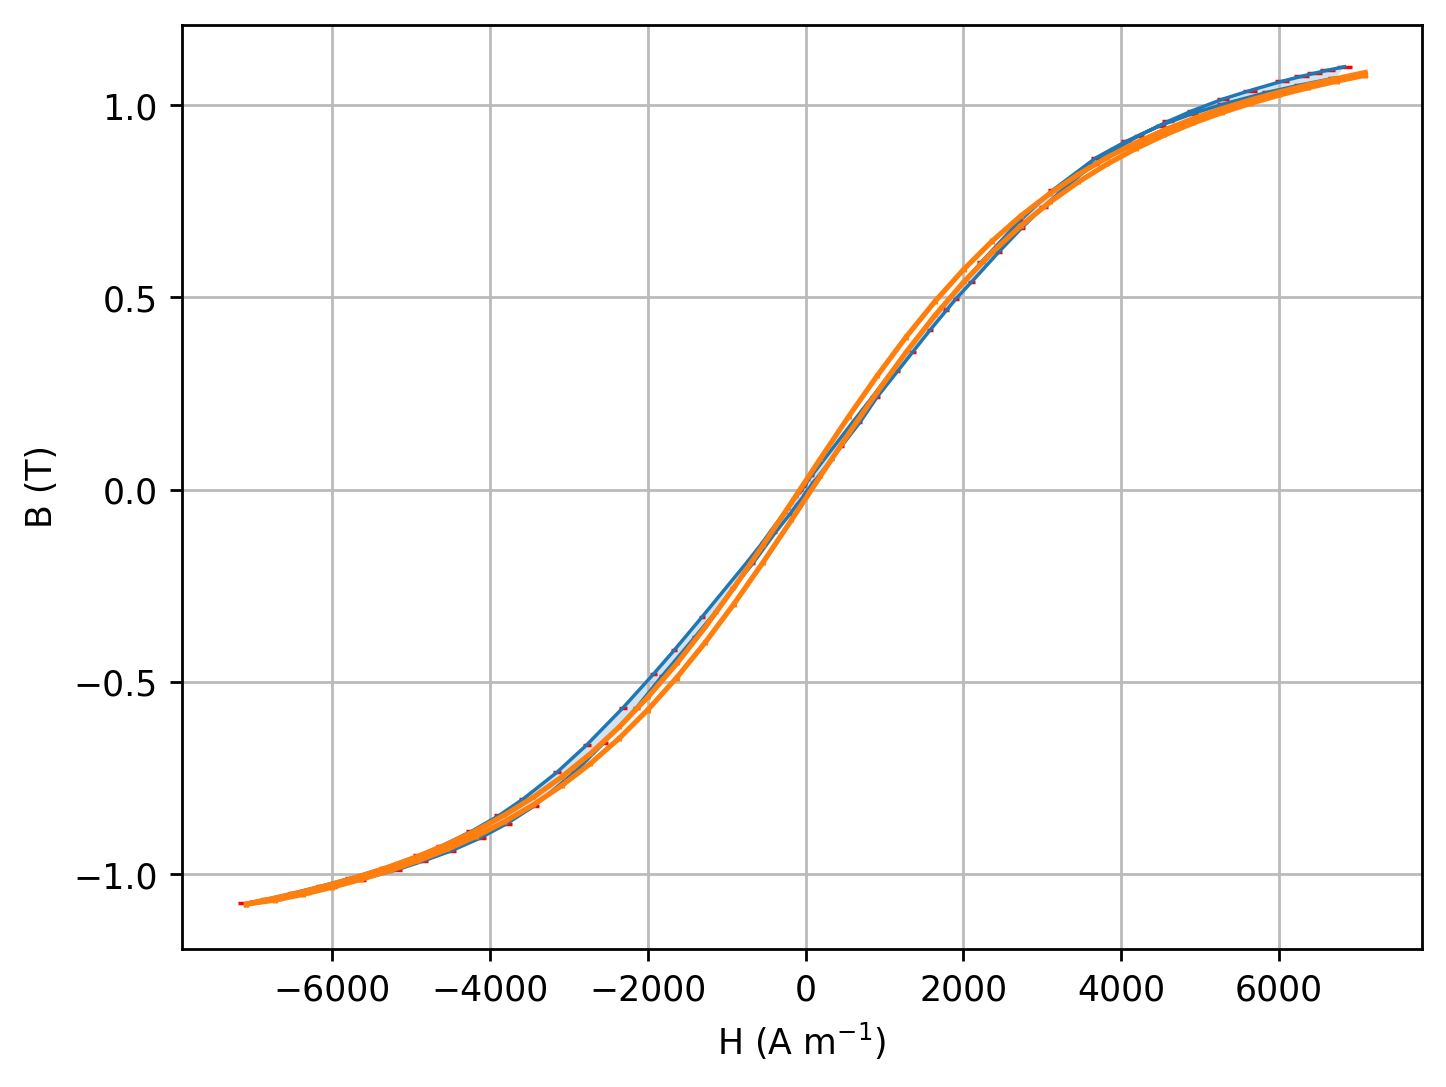

In [1638]:
X = H[1]
Y = B[1]

fig, ax = plt.subplots(dpi = 250)

s = slice(25,-1)

ax.errorbar(un.nominal_values(X[s]),un.nominal_values(Y[s]), xerr = un.std_devs(X[s]), yerr = un.std_devs(Y[s]), lw = 1, ecolor = "#ff0000", ls = "-")

ax.fill(un.nominal_values(X[s]),un.nominal_values(Y[s]), alpha = 0.2)

ax.errorbar(dflaminado["H"], dflaminado["B"], yerr = dflaminado["errB"], zorder = 10)


ax.set(xlabel = "H (A m$^{-1}$)", ylabel = "B (T)")

plt.grid(color = "#bbbbbb", zorder = 0)

plt.show()

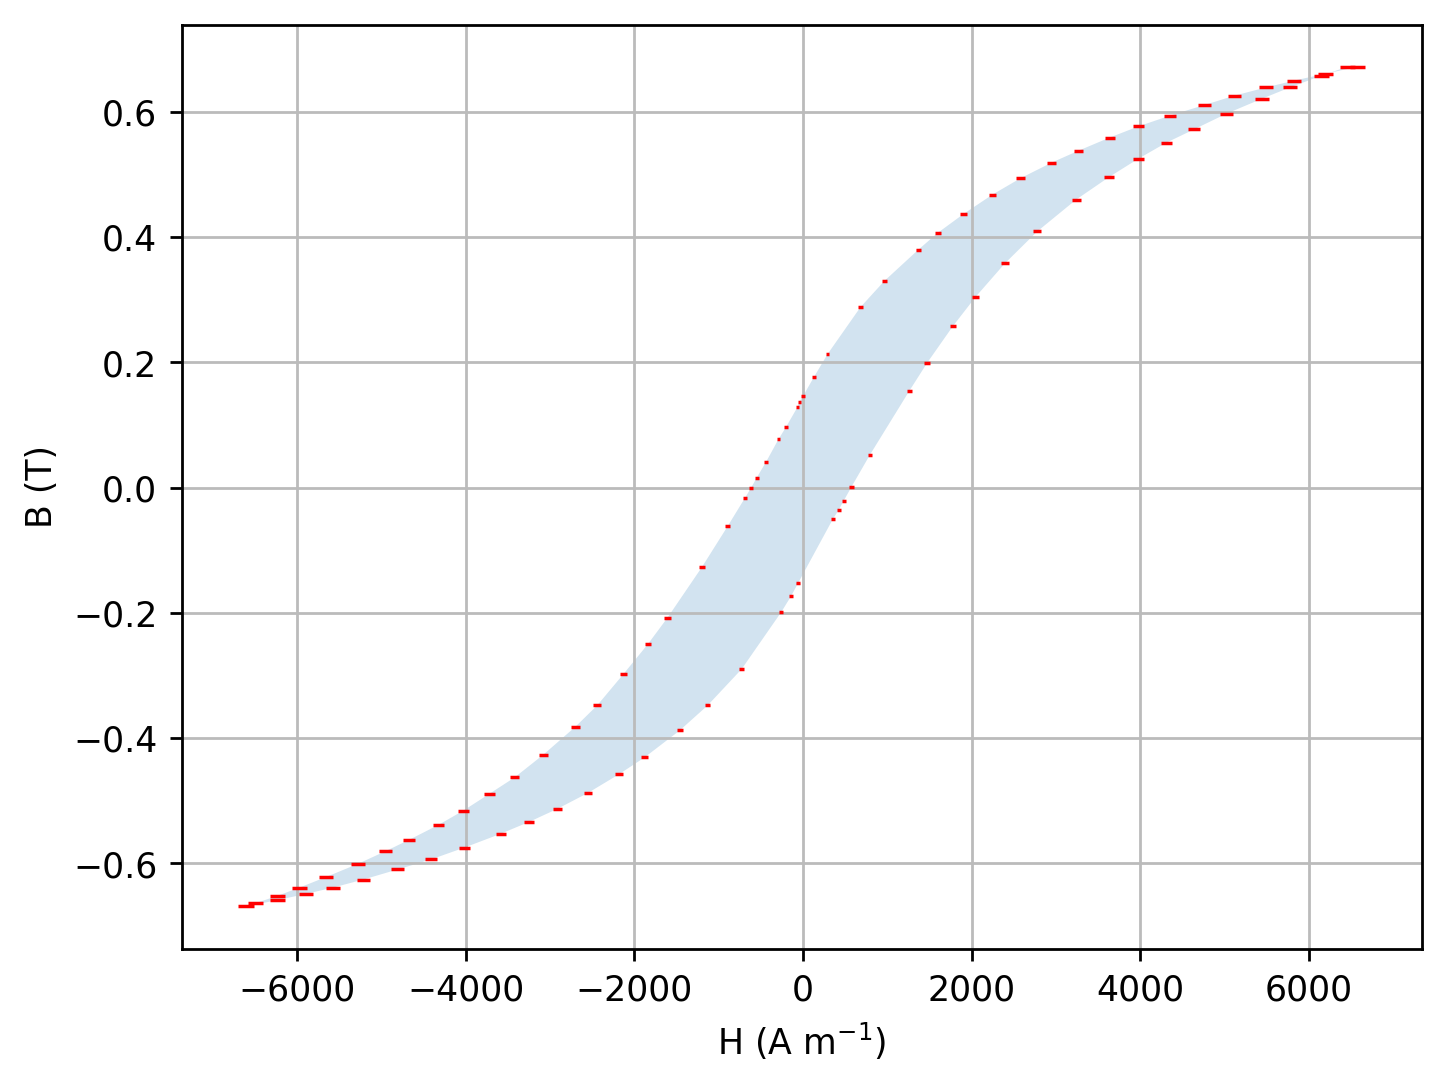

In [1639]:
X = H[0]
Y = B[0]

fig, ax = plt.subplots(dpi = 250)

s = slice(26,-1)

ax.errorbar(un.nominal_values(X[s]),un.nominal_values(Y[s]), xerr = un.std_devs(X[s]), yerr = un.std_devs(Y[s]), lw = 1, ecolor = "#ff0000", ls = "")

ax.fill(un.nominal_values(X[s]),un.nominal_values(Y[s]), alpha = 0.2)


ax.set(xlabel = "H (A m$^{-1}$)", ylabel = "B (T)")

plt.grid(color = "#bbbbbb", zorder = 0)

plt.show()